In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")

In [4]:
from sklearn.datasets import make_classification

X , y = make_classification(
    n_samples = 100 , n_features = 2 , n_informative = 1 ,
    n_redundant = 0 , n_classes = 2 , n_clusters_per_class = 1 , 
    random_state = 41 , hypercube = False , class_sep = 20  
)

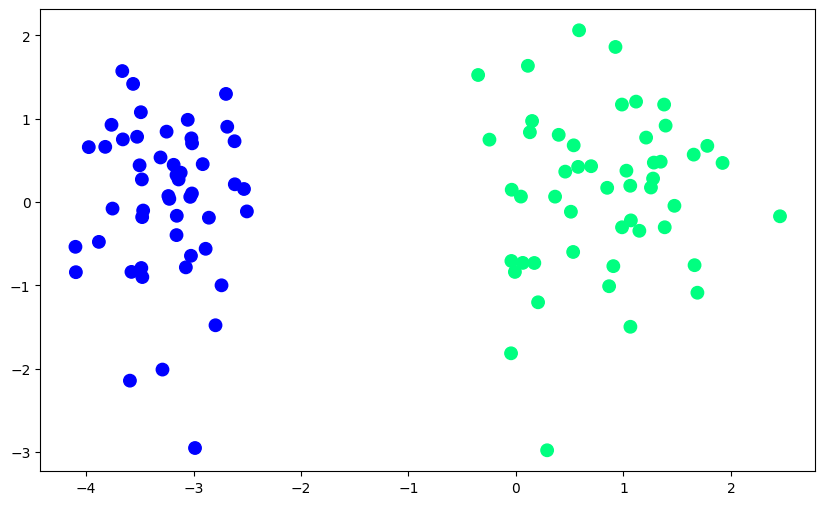

In [5]:
plt.figure(figsize = (10 , 6))
plt.scatter(X[ : , 0] , X[ : , 1] , c = y , cmap = 'winter' , s = 80)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.1 , random_state = 41)

## Scikit-Learn Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression(penalty = None , solver = 'sag')
lor.fit(X_train , y_train)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [9]:
print(lor.coef_)
print(lor.intercept_)

[[4.73495001 0.20381064]]
[5.71140667]


In [10]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, lor.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%") 

Logistic Regression model accuracy: 100.00%


In [11]:
m1 = -(lor.coef_[0][0] / lor.coef_[0][1])
b1 = -(lor.intercept_ / lor.coef_[0][1])

In [12]:
x_input1 = np.linspace(-3 , 3 , 100)
y_input1 = m1 * x_input1 + b1

## Our Logictic Regression Class Using gradient descent

In [19]:
class LogisticRegressionGD: 
    def __init__(self , epochs = 1000 , learning_rate = 0.1): 
        self.epochs = epochs
        self.learning_rate = learning_rate 
        self.coef_ = None 
        self.intercept_ = None 
        self.weights = None 
    # make the sigmoid funtion 
    def sigmoid(self , z): 
        return 1 / (1 + np.exp(-z))
        
    def fit(self , X_train , y_train): 
        m , n = X_train.shape
        # Add a bias term in X 
        X_biased = np.insert(X_train , 0 , 1 , axis = 1) 
        # Initialize the weights
        self.weights = np.ones(n + 1) # if column number is n then total coefs = n + 1

        for epoch in range(self.epochs): 
            # find the value of z
            z = np.dot(X_biased , self.weights)
            # find y_hat
            y_hat = self.sigmoid(z)  

            # now find gradient 
            gradient_of_loss = (-1 / m) * np.dot((y_train - y_hat) , X_biased)

            # update the weights 
            self.weights = self.weights - self.learning_rate * gradient_of_loss

        self.intercept_ = self.weights[0]
        self.coef_ = self.weights[1 : ]
        
    def predict_proba(self, X_test):
        m, n = X_test.shape
        X_biased = np.insert(X_test, 0, 1, axis=1)
        z = np.dot(X_biased, self.weights)
        return self.sigmoid(z) 

    def predict(self , X_test): 
        proba = self.predict_proba(X_test)
        return (proba >= 0.5).astype(int) 

In [15]:
m , n = X_train.shape
# Add a bias term in X 
X_biased = np.insert(X_train , 0 , 1 , axis = 1) 
# Initialize the weights
weights = np.ones(n + 1) # if column number is n then total coefs = n + 1

print(X_biased.shape)
print(weights.shape)

(90, 3)
(3,)


In [16]:
z = np.dot(X_biased , weights)
z.shape

(90,)

In [17]:
y_hat = sigmoid(z) 
y_hat.shape

(90,)

In [18]:
y_train.shape

(90,)

In [41]:
lor_gd = LogisticRegressionGD(epochs = 4000 , learning_rate = 0.1)
lor_gd.fit(X_train , y_train)

In [42]:
print(lor_gd.coef_)
print(lor_gd.intercept_)

[3.6404004  0.12220633]
4.1153653279875035


In [43]:
acc = accuracy_score(y_test, lor_gd.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 100.00%


In [44]:
m2 = -(lor_gd.coef_[0] / lor_gd.coef_[1])
b2 = -(lor_gd.intercept_ / lor_gd.coef_[1])

In [45]:
x_input2 = np.linspace(-3 , 3 , 100)
y_input2 = m2 * x_input2 + b2

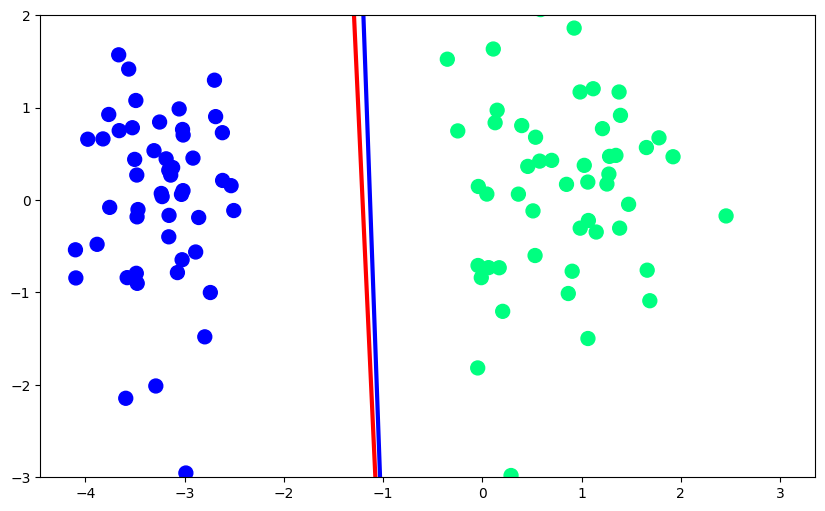

In [46]:
plt.figure(figsize=(10,6))

plt.plot(x_input1 , y_input1 , color = 'red' , linewidth = 3)
plt.plot(x_input2 , y_input2 , color = 'blue', linewidth = 3)
plt.scatter(X[ : , 0],X[ : , 1],c = y , cmap = 'winter' , s = 100)

plt.ylim(-3 , 2)
plt.show()